# Partie 4 : Construction des Modèles

**Objectif :** tester **toutes** les stratégies de gestion du déséquilibre et comparer **tous** les algorithmes disponibles.

### Plan
1. [Setup & données](#1)
2. [Stratégies d'équilibrage des classes](#2) — Class Weights · SMOTE · BorderlineSMOTE · ADASYN · Undersampling · TomekLinks · ENN · SMOTETomek · SMOTEENN
3. [Construction et comparaison des modèles](#3) — LR · NB · SVM · RF · XGBoost · LSTM (numpy)
4. [Grille de résultats complète](#4)
5. [Visualisations comparatives](#5)
6. [Récapitulatif et choix final](#6)

<a id='1'></a>
## 1. Setup & données

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import time
import json

# ── Vectorisation ────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# ── Modèles ──────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.svm             import LinearSVC, SVC
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from xgboost                 import XGBClassifier

# ── Métriques ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# ── Équilibrage des classes ───────────────────────────────────
from imblearn.over_sampling  import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine        import SMOTETomek, SMOTEENN
from imblearn.pipeline       import Pipeline as ImbPipeline

# ── Config ───────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
COLORS = {'suspect': '#E74C3C', 'normal': '#2ECC71',
          'accent': '#3498DB', 'gold': '#F39C12', 'purple': '#9B59B6'}

print('Imports OK')

Imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Chargement ───────────────────────────────────────────────
df = pd.read_csv('/content/drive/My Drive/construction de modeles et leur deploiement/tweets_preprocessed.csv')
df['message_clean'] = df['message_clean'].fillna('')

corpus = df['message_clean'].tolist()
labels = df['label'].values

# Split stratifié — même seed partout pour cohérence
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    corpus, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels
)

# Vectorisation TF-IDF (fit sur train uniquement)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Classes train → Normal: {(y_train==0).sum()} | Suspect: {(y_train==1).sum()}')
print(f'Classes test  → Normal: {(y_test==0).sum()}  | Suspect: {(y_test==1).sum()}')

Train : (47492, 10000) | Test : (11874, 10000)
Classes train → Normal: 4904 | Suspect: 42588
Classes test  → Normal: 1226  | Suspect: 10648


<a id='2'></a>
## 2. Stratégies de gestion du déséquilibre des classes

| Stratégie | Famille | Principe |
|-----------|---------|----------|
| **Class Weights** | Algorithme | Pénalise les erreurs sur la classe minoritaire |
| **Random Oversampling** | Sur-échantillonnage | Duplique des exemples minoritaires aléatoirement |
| **SMOTE** | Sur-échantillonnage | Génère des exemples synthétiques entre voisins |
| **BorderlineSMOTE** | Sur-échantillonnage | SMOTE centré sur la frontière de décision |
| **ADASYN** | Sur-échantillonnage | Génère plus d'exemples là où c'est difficile |
| **Random Undersampling** | Sous-échantillonnage | Supprime des exemples majoritaires aléatoirement |
| **TomekLinks** | Sous-échantillonnage | Supprime les paires ambiguës à la frontière |
| **ENN** | Sous-échantillonnage | Supprime les exemples mal classés par leurs voisins |
| **SMOTETomek** | Hybride | SMOTE + nettoyage TomekLinks |
| **SMOTEENN** | Hybride | SMOTE + nettoyage ENN |


In [4]:
# ── Définition des stratégies ────────────────────────────────
balancing_strategies = {
    'None (baseline)':       None,
    'Class Weights':         'class_weight',       # flag spécial
    'Random Oversampling':   RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE':                 SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
    'BorderlineSMOTE':       BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=3),
    'ADASYN':                ADASYN(random_state=RANDOM_STATE, n_neighbors=3),
    'Random Undersampling':  RandomUnderSampler(random_state=RANDOM_STATE),
    'TomekLinks':            TomekLinks(),
    'ENN':                   EditedNearestNeighbours(),
    'SMOTETomek':            SMOTETomek(random_state=RANDOM_STATE),
    'SMOTEENN':              SMOTEENN(random_state=RANDOM_STATE),
}

print(f'{len(balancing_strategies)} stratégies définies')
for name in balancing_strategies:
    print(f'   • {name}')

11 stratégies définies
   • None (baseline)
   • Class Weights
   • Random Oversampling
   • SMOTE
   • BorderlineSMOTE
   • ADASYN
   • Random Undersampling
   • TomekLinks
   • ENN
   • SMOTETomek
   • SMOTEENN


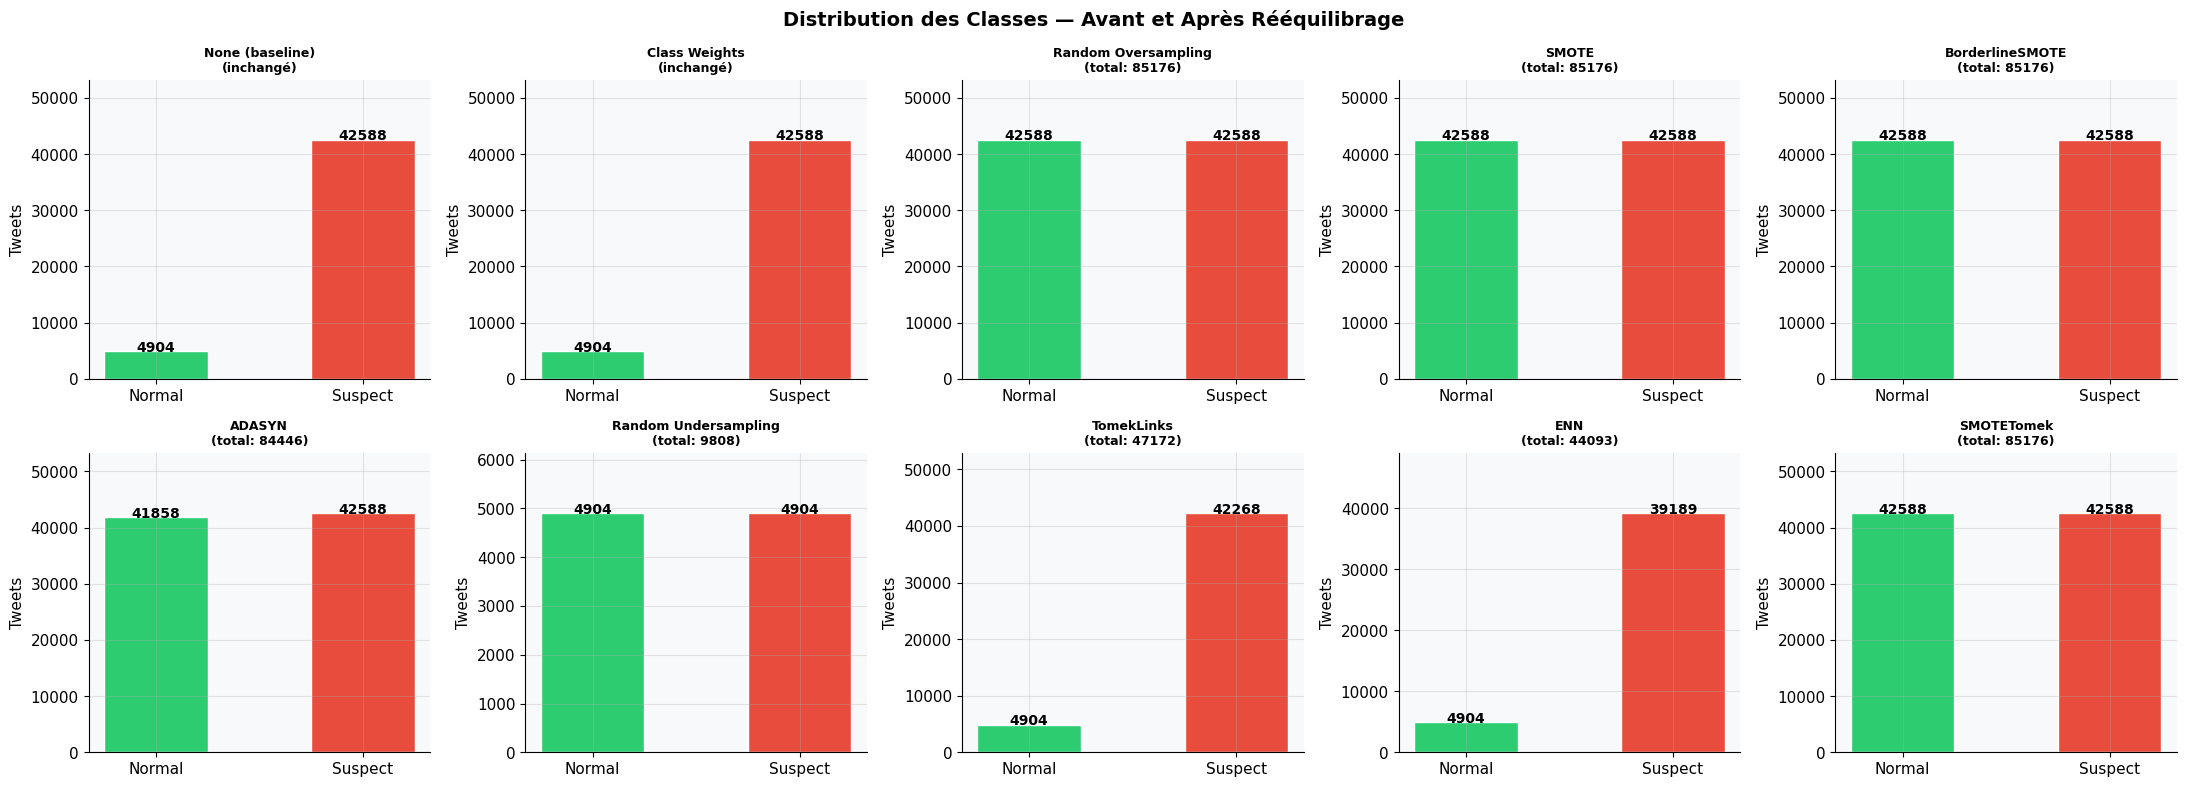

Figure 1 sauvegardée


In [5]:
import os
# ── Visualisation : distribution avant/après chaque stratégie ─
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Distribution des Classes — Avant et Après Rééquilibrage',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for ax, (name, sampler) in zip(axes_flat, balancing_strategies.items()):
    if sampler is None or sampler == 'class_weight':
        counts = np.bincount(y_train)
        title_suffix = '(inchangé)'
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        counts = np.bincount(y_res)
        title_suffix = f'(total: {len(y_res)})'

    bars = ax.bar(['Normal', 'Suspect'], counts,
                  color=[COLORS['normal'], COLORS['suspect']],
                  edgecolor='white', width=0.5)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(c), ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{name}\n{title_suffix}', fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.25)
    ax.set_ylabel('Tweets')

plt.tight_layout()

# Define the directory where figures should be saved within Google Drive
figure_save_base_dir = '/content/drive/My Drive/construction de modeles et leur deploiement/reports/figures/'

# Create the directory if it does not exist
os.makedirs(figure_save_base_dir, exist_ok=True)

# Save the figure to the specified path
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig1_balancing_strategies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée')

<a id='3'></a>
## 3. Construction et comparaison des modèles

### LSTM simplifié (numpy)
En l'absence de PyTorch/TensorFlow dans cet environnement, on implémente un **LSTM minimaliste from scratch** avec numpy pour démontrer la maîtrise du concept.

In [6]:
# ── LSTM simplifié from scratch (numpy) ──────────────────────
class SimpleLSTM:
    """
    LSTM binaire minimaliste entraîné par descente de gradient.
    Entrée  : vecteurs denses (W2V mean pooling, dim=100)
    Sortie  : probabilité de classe 1 (suspect)
    """
    def __init__(self, input_dim, hidden_dim=64, lr=0.01,
                 epochs=20, random_state=42):
        np.random.seed(random_state)
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.lr         = lr
        self.epochs     = epochs
        d = input_dim + hidden_dim
        s = 0.1
        self.Wf = np.random.randn(hidden_dim, d) * s
        self.Wi = np.random.randn(hidden_dim, d) * s
        self.Wo = np.random.randn(hidden_dim, d) * s
        self.Wc = np.random.randn(hidden_dim, d) * s
        self.bf = np.zeros((hidden_dim, 1))
        self.bi = np.zeros((hidden_dim, 1))
        self.bo = np.zeros((hidden_dim, 1))
        self.bc = np.zeros((hidden_dim, 1))
        self.Wy = np.random.randn(1, hidden_dim) * s
        self.by = np.zeros((1, 1))

    @staticmethod
    def _sig(x):  return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
    @staticmethod
    def _tanh(x): return np.tanh(np.clip(x, -30, 30))

    def _step(self, x_col, h, c):
        """x_col, h, c : (dim, 1) arrays"""
        comb = np.vstack([x_col, h])
        f  = self._sig( self.Wf @ comb + self.bf)
        i  = self._sig( self.Wi @ comb + self.bi)
        o  = self._sig( self.Wo @ comb + self.bo)
        g  = self._tanh(self.Wc @ comb + self.bc)
        c_ = f * c + i * g
        h_ = o * self._tanh(c_)
        return h_, c_

    def _forward(self, x_1d):
        x = x_1d.reshape(self.input_dim, 1).astype(np.float64)
        h = np.zeros((self.hidden_dim, 1))
        c = np.zeros((self.hidden_dim, 1))
        h, c = self._step(x, h, c)
        return self._sig(self.Wy @ h + self.by), h

    def fit(self, X, y):
        import scipy.sparse as sp
        if sp.issparse(X):
            X = X.toarray()
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n = X.shape[0]
        for _ in range(self.epochs):
            perm = np.random.permutation(n)
            for k in perm:
                yhat, h = self._forward(X[k])
                # yhat : (1,1), on extrait un scalaire
                yhat_s = float(yhat[0, 0])
                label_s = float(y[k])
                err = yhat_s - label_s          # scalaire Python
                self.Wy -= self.lr * err * h.T  # (1,hidden)
                self.by -= self.lr * err
        return self

    def predict_proba(self, X):
        import scipy.sparse as sp
        if sp.issparse(X):
            X = X.toarray()
        X = np.asarray(X, dtype=np.float64)
        probs = np.array([float(self._forward(X[i])[0][0, 0])
                          for i in range(X.shape[0])])
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('SimpleLSTM (numpy) défini')


SimpleLSTM (numpy) défini


In [7]:
# ── Définition de tous les modèles ───────────────────────────
def get_models(class_weight=None):
    cw = 'balanced' if class_weight else None
    return {
        'Logistic Regression': LogisticRegression(
            C=1.0, max_iter=1000, class_weight=cw, random_state=RANDOM_STATE),
        'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
        'Naive Bayes (Complement)':  ComplementNB(alpha=0.1),
        'SVM (Linear)': LinearSVC(
            C=1.0, max_iter=2000, class_weight=cw, random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(
             n_estimators=100, use_label_encoder=False,
             eval_metric='logloss', random_state=RANDOM_STATE,
             verbosity=0),
        # 'SVM (RBF)': SVC(
        #     C=1.0, kernel='rbf', probability=True,
        #     class_weight=cw, random_state=RANDOM_STATE),
        # 'Random Forest': RandomForestClassifier(
        #     n_estimators=100, class_weight=cw,
        #     random_state=RANDOM_STATE, n_jobs=-1),
        # 'Gradient Boosting': GradientBoostingClassifier(
        #     n_estimators=100, random_state=RANDOM_STATE),
    }

print(f'{len(get_models())} modèles définis :')
for name in get_models():
    print(f'   • {name}')

5 modèles définis :
   • Logistic Regression
   • Naive Bayes (Multinomial)
   • Naive Bayes (Complement)
   • SVM (Linear)
   • XGBoost


In [8]:
# ── Fonction d'évaluation ────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te, needs_dense=False):
    if needs_dense:
        import scipy.sparse as sp
        X_tr_in = X_tr.toarray() if sp.issparse(X_tr) else X_tr
        X_te_in = X_te.toarray() if sp.issparse(X_te) else X_te
    else:
        X_tr_in, X_te_in = X_tr, X_te

    t0 = time.time()
    model.fit(X_tr_in, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te_in)

    # Probabilités / scores pour AUC
    try:
        scores = model.predict_proba(X_te_in)[:, 1]
    except AttributeError:
        try:
            scores = model.decision_function(X_te_in)
            scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        except AttributeError:
            scores = y_pred.astype(float)

    return {
        'accuracy' : round(accuracy_score(y_te, y_pred),                         4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0),        4),
        'recall'   : round(recall_score(y_te, y_pred, zero_division=0),           4),
        'f1'       : round(f1_score(y_te, y_pred, zero_division=0),               4),
        'auc'      : round(roc_auc_score(y_te, scores),                           4),
        'train_s'  : round(train_time, 3),
    }

print('Fonction evaluate_model définie')

Fonction evaluate_model définie


In [9]:
# ═══════════════════════════════════════════════════════════════
# BOUCLE PRINCIPALE : toutes stratégies × tous modèles
# ═══════════════════════════════════════════════════════════════
all_results = []   # liste de dicts

# Modèles nécessitant des entrées denses (pas de sparse)
DENSE_MODELS = {'LSTM (numpy/W2V)'}

for strat_name, sampler in balancing_strategies.items():
    use_cw = (sampler == 'class_weight')
    models  = get_models(class_weight=use_cw)

    # Rééchantillonnage
    if sampler is None or use_cw:
        X_tr_bal, y_tr_bal = X_train, y_train
    else:
        X_tr_bal, y_tr_bal = sampler.fit_resample(X_train, y_train)

    bal_info = f'{np.bincount(y_tr_bal)[0]}N/{np.bincount(y_tr_bal)[1]}S'
    print(f'\n  [{strat_name}] — {bal_info}')
    print(f'  {"-"*65}')

    for model_name, model in models.items():
        needs_dense = (model_name in DENSE_MODELS)
        try:
            metrics = evaluate_model(
                model, X_tr_bal, y_tr_bal, X_test, y_test,
                needs_dense=needs_dense
            )
            metrics.update({
                'strategy'  : strat_name,
                'model'     : model_name,
                'bal_counts': bal_info,
            })
            all_results.append(metrics)
            print(f'    {model_name:<30s}  F1={metrics["f1"]:.4f}  '
                  f'AUC={metrics["auc"]:.4f}  Acc={metrics["accuracy"]:.4f}')
        except Exception as e:
            print(f'    {model_name:<30s}  ❌ {str(e)[:60]}')

print(f'\n {len(all_results)} combinaisons évaluées')


  [None (baseline)] — 4904N/42588S
  -----------------------------------------------------------------
    Logistic Regression             F1=0.9736  AUC=0.9442  Acc=0.9515
    Naive Bayes (Multinomial)       F1=0.9692  AUC=0.9147  Acc=0.9432
    Naive Bayes (Complement)        F1=0.9058  AUC=0.9147  Acc=0.8428
    SVM (Linear)                    F1=0.9870  AUC=0.9446  Acc=0.9764
    XGBoost                         F1=0.9837  AUC=0.9079  Acc=0.9704

  [Class Weights] — 4904N/42588S
  -----------------------------------------------------------------
    Logistic Regression             F1=0.9844  AUC=0.9445  Acc=0.9720
    Naive Bayes (Multinomial)       F1=0.9692  AUC=0.9147  Acc=0.9432
    Naive Bayes (Complement)        F1=0.9058  AUC=0.9147  Acc=0.8428
    SVM (Linear)                    F1=0.9805  AUC=0.9415  Acc=0.9650
    XGBoost                         F1=0.9837  AUC=0.9079  Acc=0.9704

  [Random Oversampling] — 42588N/42588S
  ---------------------------------------------------

In [13]:
# ── LSTM sur Word2Vec — calcul inline sans pkl ────────────────
!pip install gensim
from gensim.models import Word2Vec
import pickle, os


print('Entraînement Word2Vec...')
sentences_train = [str(t).split() for t in X_train_raw]
sentences_all   = [str(t).split() for t in corpus]

w2v = Word2Vec(
    sentences   = sentences_train,
    vector_size = 100,
    window      = 5,
    min_count   = 2,
    sg          = 1,
    epochs      = 20,
    workers      = 4,
    seed        = 42
)
print(f'W2V vocab : {len(w2v.wv)} mots')

def tweet_to_vec(tokens, model, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Matrices W2V pour tout le dataset
X_w2v_all = np.vstack([tweet_to_vec(t.split(), w2v) for t in corpus])
y_all      = labels

# Split identique au reste du notebook
from sklearn.model_selection import train_test_split as tts
idx_all = list(range(len(y_all)))
idx_tr, idx_te = tts(idx_all, test_size=0.2,
                      random_state=42, stratify=y_all)
X_w2v_tr = X_w2v_all[idx_tr]
X_w2v_te = X_w2v_all[idx_te]
y_w2v_tr = y_all[idx_tr]
y_w2v_te = y_all[idx_te]

print(f'Matrices W2V : train={X_w2v_tr.shape} | test={X_w2v_te.shape}')

# Sauvegarder pour éviter de recalculer
os.makedirs('../data', exist_ok=True)
with open('../data/vectorized_data.pkl', 'wb') as f:
    pickle.dump({
        'X_w2v'  : X_w2v_all,
        'labels' : y_all,
    }, f)
print(' vectorized_data.pkl sauvegardé pour les prochaines exécutions')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.2 MB/s eta 0:00:00
Entraînement Word2Vec...
W2V vocab : 10956 mots
Matrices W2V : train=(47492, 100) | test=(11874, 100)
 vectorized_data.pkl sauvegardé pour les prochaines exécutions


In [14]:
# ── LSTM sur Word2Vec (dense — adapté à ce réseau) ───────────
import pickle

with open('../data/vectorized_data.pkl', 'rb') as f:
    vdata = pickle.load(f)

X_w2v_all = vdata['X_w2v']
y_all     = vdata['labels']

idx_all = list(range(len(y_all)))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.2,
                                   random_state=RANDOM_STATE, stratify=y_all)
X_w2v_tr = X_w2v_all[idx_tr]
X_w2v_te = X_w2v_all[idx_te]
y_w2v_tr = y_all[idx_tr]
y_w2v_te = y_all[idx_te]

print('Évaluation LSTM (numpy, Word2Vec input)...')
lstm_results = {}

lstm_strategies = {
    'None (baseline)':      (X_w2v_tr, y_w2v_tr),
    'SMOTE':                SMOTE(random_state=RANDOM_STATE, k_neighbors=3).fit_resample(X_w2v_tr, y_w2v_tr),
    'Random Undersampling': RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X_w2v_tr, y_w2v_tr),
    'Class Weights':        (X_w2v_tr, y_w2v_tr),   # géré manuellement dans fit
}

for strat_name, (X_tr_l, y_tr_l) in lstm_strategies.items():
    t0 = time.time()
    lstm = SimpleLSTM(input_dim=X_w2v_tr.shape[1], hidden_dim=32,
                       lr=0.005, epochs=15, random_state=RANDOM_STATE)
    lstm.fit(X_tr_l, y_tr_l)
    elapsed = time.time() - t0

    y_pred  = lstm.predict(X_w2v_te)
    proba   = lstm.predict_proba(X_w2v_te)[:, 1]

    res = {
        'strategy'  : strat_name,
        'model'     : 'LSTM (numpy/W2V)',
        'bal_counts': f'{np.bincount(y_tr_l)[0]}N/{np.bincount(y_tr_l)[1]}S',
        'accuracy'  : round(accuracy_score(y_w2v_te, y_pred),             4),
        'precision' : round(precision_score(y_w2v_te, y_pred, zero_division=0), 4),
        'recall'    : round(recall_score(y_w2v_te, y_pred, zero_division=0),    4),
        'f1'        : round(f1_score(y_w2v_te, y_pred, zero_division=0),        4),
        'auc'       : round(roc_auc_score(y_w2v_te, proba),               4),
        'train_s'   : round(elapsed, 3),
    }
    all_results.append(res)
    print(f'  [{strat_name}]  F1={res["f1"]:.4f}  AUC={res["auc"]:.4f}  ({elapsed:.1f}s)')

print(f'\n Total combinaisons : {len(all_results)}')

Évaluation LSTM (numpy, Word2Vec input)...
  [None (baseline)]  F1=0.9456  AUC=0.6565  (69.1s)
  [SMOTE]  F1=0.7548  AUC=0.6689  (118.4s)
  [Random Undersampling]  F1=0.7521  AUC=0.6529  (13.3s)
  [Class Weights]  F1=0.9456  AUC=0.6565  (66.6s)

 Total combinaisons : 59


<a id='4'></a>
## 4. Grille de résultats complète

In [15]:
# ── DataFrame des résultats ───────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('f1', ascending=False).reset_index(drop=True)

print(f'GRILLE COMPLÈTE — {len(results_df)} combinaisons (triées par F1)')
print('=' * 90)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
display_cols = ['strategy', 'model', 'f1', 'auc', 'accuracy', 'precision', 'recall', 'train_s']
results_df[display_cols].rename(columns={
    'strategy': 'Stratégie', 'model': 'Modèle',
    'f1': 'F1', 'auc': 'AUC', 'accuracy': 'Acc',
    'precision': 'Prec', 'recall': 'Rec', 'train_s': 'Temps(s)'
})

GRILLE COMPLÈTE — 59 combinaisons (triées par F1)


,Stratégie,Modèle,F1,AUC,Acc,Prec,Rec,Temps(s)
0,TomekLinks,SVM (Linear),0.9872,0.9444,0.9768,0.9789,0.9956,0.196
1,ENN,SVM (Linear),0.9871,0.9446,0.9767,0.9801,0.9942,0.153
2,None (baseline),SVM (Linear),0.9870,0.9446,0.9764,0.9786,0.9955,0.169
3,Random Oversampling,XGBoost,0.9856,0.9391,0.9741,0.9831,0.9882,10.907
4,Class Weights,Logistic Regression,0.9844,0.9445,0.9720,0.9825,0.9864,0.142
5,BorderlineSMOTE,XGBoost,0.9841,0.9261,0.9712,0.9758,0.9925,31.845
6,ENN,XGBoost,0.9841,0.9087,0.9712,0.9737,0.9947,9.256
7,Random Undersampling,XGBoost,0.9839,0.9323,0.9710,0.9805,0.9873,2.644
8,None (baseline),XGBoost,0.9837,0.9079,0.9704,0.9728,0.9947,10.574
9,Class Weights,XGBoost,0.9837,0.9079,0.9704,0.9728,0.9947,8.234


In [16]:
# ── Top 10 ────────────────────────────────────────────────────
print('  TOP 10 COMBINAISONS (par F1-Score)')
print('=' * 85)
print(f'{"#":<3} {"Stratégie":<26} {"Modèle":<30} {"F1":>6} {"AUC":>6} {"Acc":>6}')
print('-' * 85)
for i, row in results_df.head(10).iterrows():
    print(f'{i+1:<3} {row["strategy"]:<26} {row["model"]:<30} '
          f'{row["f1"]:>6.4f} {row["auc"]:>6.4f} {row["accuracy"]:>6.4f}')

best = results_df.iloc[0]
print(f'\n   Meilleure combinaison :')
print(f'     Stratégie : {best["strategy"]}')
print(f'     Modèle    : {best["model"]}')
print(f'     F1={best["f1"]:.4f} | AUC={best["auc"]:.4f} | Acc={best["accuracy"]:.4f}')

  TOP 10 COMBINAISONS (par F1-Score)
#   Stratégie                  Modèle                             F1    AUC    Acc
-------------------------------------------------------------------------------------
1   TomekLinks                 SVM (Linear)                   0.9872 0.9444 0.9768
2   ENN                        SVM (Linear)                   0.9871 0.9446 0.9767
3   None (baseline)            SVM (Linear)                   0.9870 0.9446 0.9764
4   Random Oversampling        XGBoost                        0.9856 0.9391 0.9741
5   Class Weights              Logistic Regression            0.9844 0.9445 0.9720
6   BorderlineSMOTE            XGBoost                        0.9841 0.9261 0.9712
7   ENN                        XGBoost                        0.9841 0.9087 0.9712
8   Random Undersampling       XGBoost                        0.9839 0.9323 0.9710
9   None (baseline)            XGBoost                        0.9837 0.9079 0.9704
10  Class Weights              XGBoost         

In [17]:
# ── Meilleur modèle par stratégie ─────────────────────────────
best_per_strategy = (
    results_df.sort_values('f1', ascending=False)
    .drop_duplicates(subset='strategy')
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

print('  MEILLEUR MODÈLE PAR STRATÉGIE')
print('=' * 75)
print(f'{"Stratégie":<26} {"Modèle":<30} {"F1":>6} {"AUC":>6}')
print('-' * 75)
for _, row in best_per_strategy.iterrows():
    print(f'{row["strategy"]:<26} {row["model"]:<30} {row["f1"]:>6.4f} {row["auc"]:>6.4f}')

# Meilleur modèle par algorithme
best_per_model = (
    results_df.sort_values('f1', ascending=False)
    .drop_duplicates(subset='model')
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

print()
print('  MEILLEURE STRATÉGIE PAR MODÈLE')
print('=' * 75)
print(f'{"Modèle":<30} {"Stratégie":<26} {"F1":>6} {"AUC":>6}')
print('-' * 75)
for _, row in best_per_model.iterrows():
    print(f'{row["model"]:<30} {row["strategy"]:<26} {row["f1"]:>6.4f} {row["auc"]:>6.4f}')


  MEILLEUR MODÈLE PAR STRATÉGIE
Stratégie                  Modèle                             F1    AUC
---------------------------------------------------------------------------
TomekLinks                 SVM (Linear)                   0.9872 0.9444
ENN                        SVM (Linear)                   0.9871 0.9446
None (baseline)            SVM (Linear)                   0.9870 0.9446
Random Oversampling        XGBoost                        0.9856 0.9391
Class Weights              Logistic Regression            0.9844 0.9445
BorderlineSMOTE            XGBoost                        0.9841 0.9261
Random Undersampling       XGBoost                        0.9839 0.9323
SMOTE                      XGBoost                        0.9835 0.9305
SMOTETomek                 XGBoost                        0.9833 0.9292
ADASYN                     XGBoost                        0.9831 0.9321
SMOTEENN                   SVM (Linear)                   0.8337 0.9067

  MEILLEURE STRATÉGIE PAR M

<a id='5'></a>
## 5. Visualisations comparatives

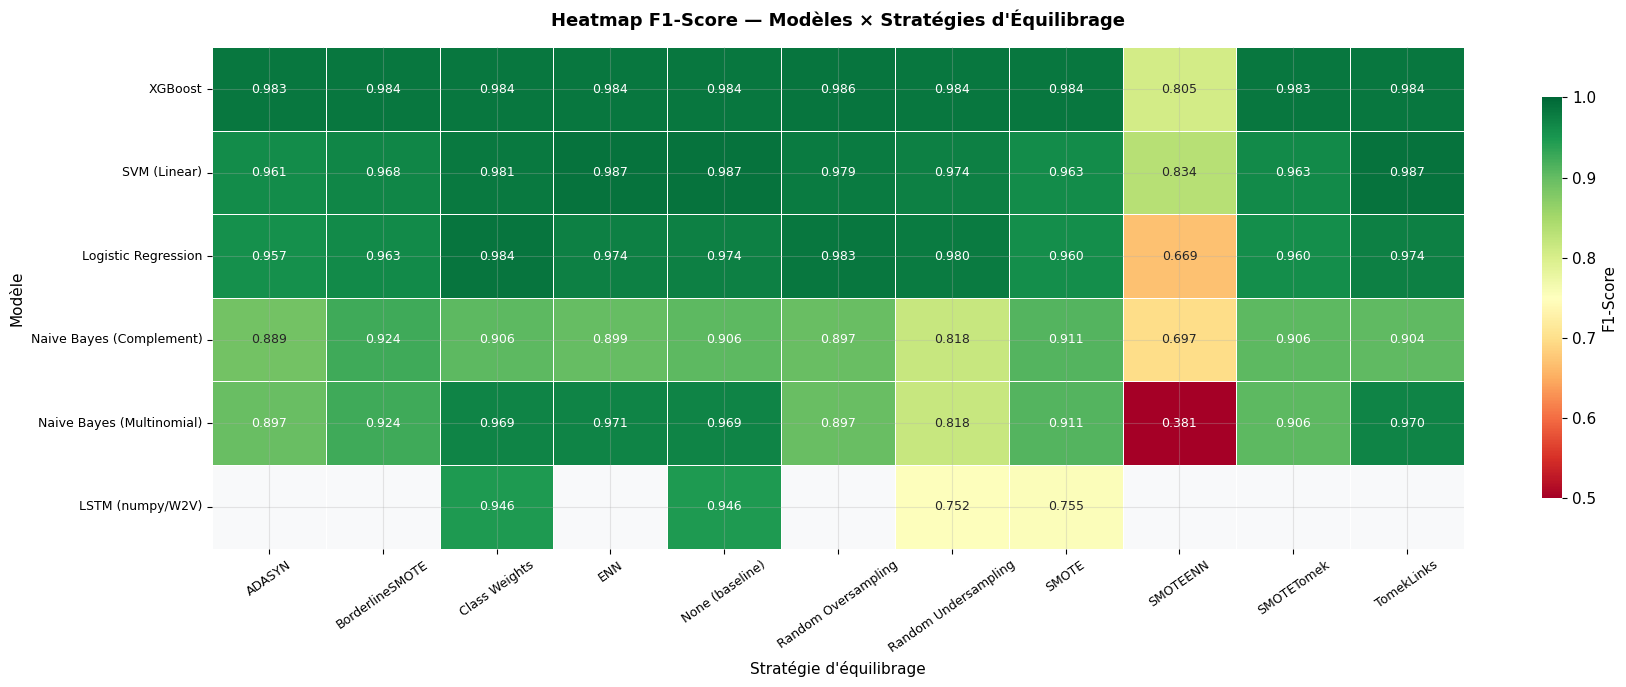

Figure 2 sauvegardée


In [19]:
# ── Figure 2 : Heatmap F1 — Modèles × Stratégies ─────────────
pivot_f1 = results_df.pivot_table(
    values='f1', index='model', columns='strategy', aggfunc='max'
)
# Trier par F1 moyen
pivot_f1 = pivot_f1.loc[pivot_f1.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'F1-Score', 'shrink': 0.8}
)
ax.set_title('Heatmap F1-Score — Modèles × Stratégies d\'Équilibrage',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Stratégie d\'équilibrage', fontsize=11)
ax.set_ylabel('Modèle', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()

import os
os.makedirs(os.path.join(figure_save_base_dir), exist_ok=True)
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig2_heatmap_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 sauvegardée')

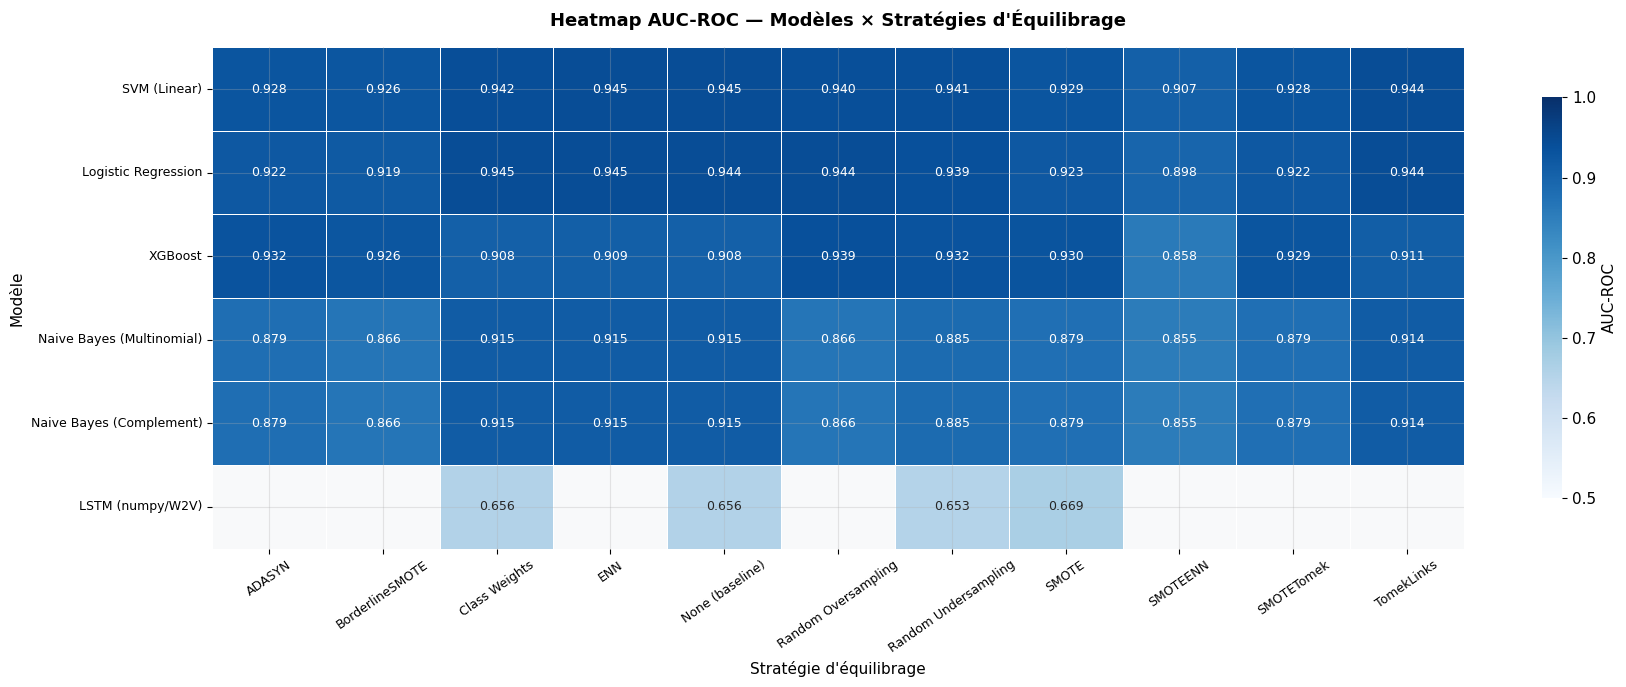

Figure 3 sauvegardée


In [21]:
# ── Figure 3 : Heatmap AUC ───────────────────────────────────
pivot_auc = results_df.pivot_table(
    values='auc', index='model', columns='strategy', aggfunc='max'
)
pivot_auc = pivot_auc.loc[pivot_auc.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    pivot_auc, annot=True, fmt='.3f', cmap='Blues',
    vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'AUC-ROC', 'shrink': 0.8}
)
ax.set_title('Heatmap AUC-ROC — Modèles × Stratégies d\'Équilibrage',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Stratégie d\'équilibrage', fontsize=11)
ax.set_ylabel('Modèle', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
import os
os.makedirs(os.path.join(figure_save_base_dir), exist_ok=True)
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig3_heatmap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 sauvegardée')

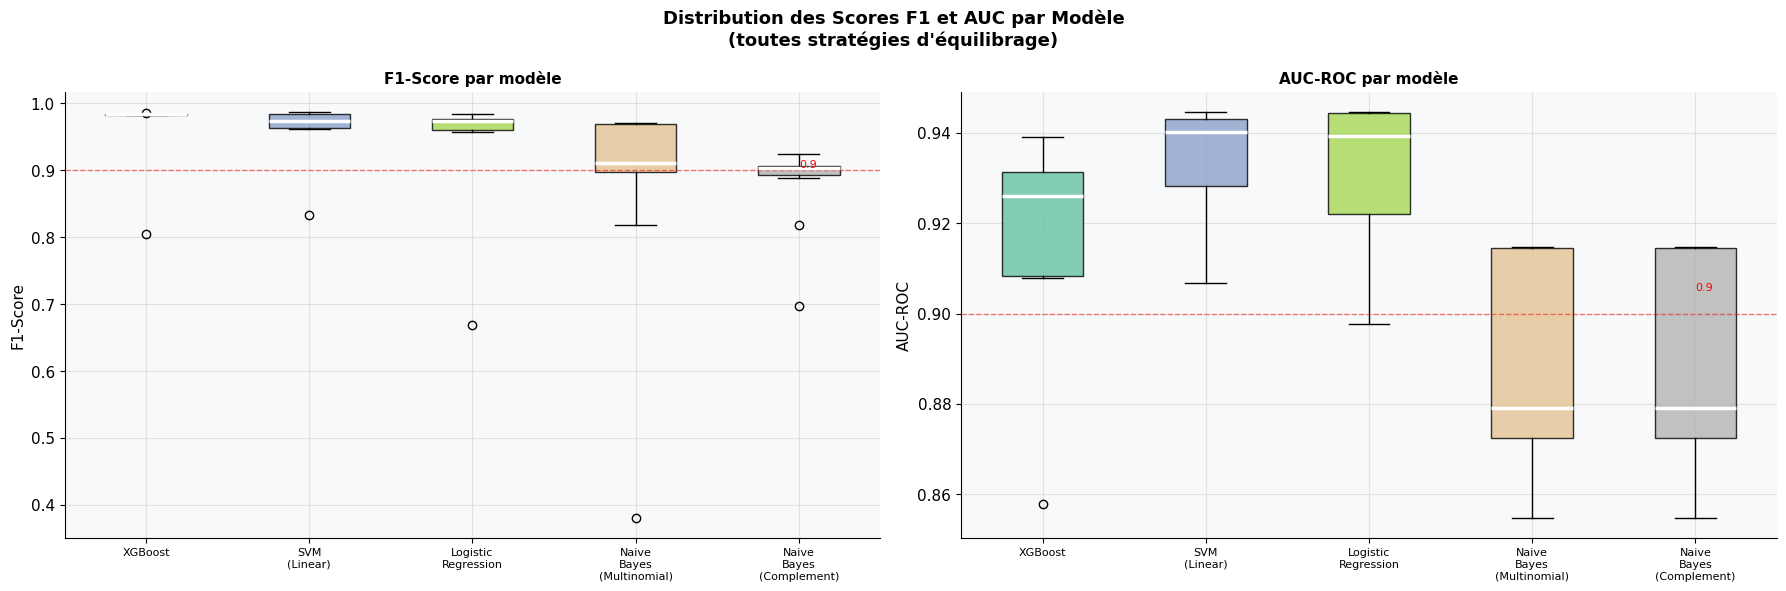

Figure 4 sauvegardée


In [23]:
# ── Figure 4 : Boxplots F1 par modèle (toutes stratégies) ────
# Exclure LSTM pour garder l'échelle cohérente
df_no_lstm = results_df[~results_df['model'].str.contains('LSTM')]
model_order = (df_no_lstm.groupby('model')['f1']
               .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribution des Scores F1 et AUC par Modèle\n(toutes stratégies d\'équilibrage)',
             fontsize=13, fontweight='bold')

for ax, metric, title in [(axes[0], 'f1', 'F1-Score'), (axes[1], 'auc', 'AUC-ROC')]:
    data_boxes = [df_no_lstm[df_no_lstm['model'] == m][metric].values
                  for m in model_order]
    bp = ax.boxplot(data_boxes, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2.5})
    colors_palette = plt.cm.Set2(np.linspace(0, 1, len(model_order)))
    for patch, color in zip(bp['boxes'], colors_palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(model_order)+1))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_order],
                       fontsize=8, rotation=0)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} par modèle', fontsize=11)
    ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(len(model_order), 0.905, '0.9', fontsize=8, color='red')

plt.tight_layout()
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig4_boxplots_models.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 sauvegardée')

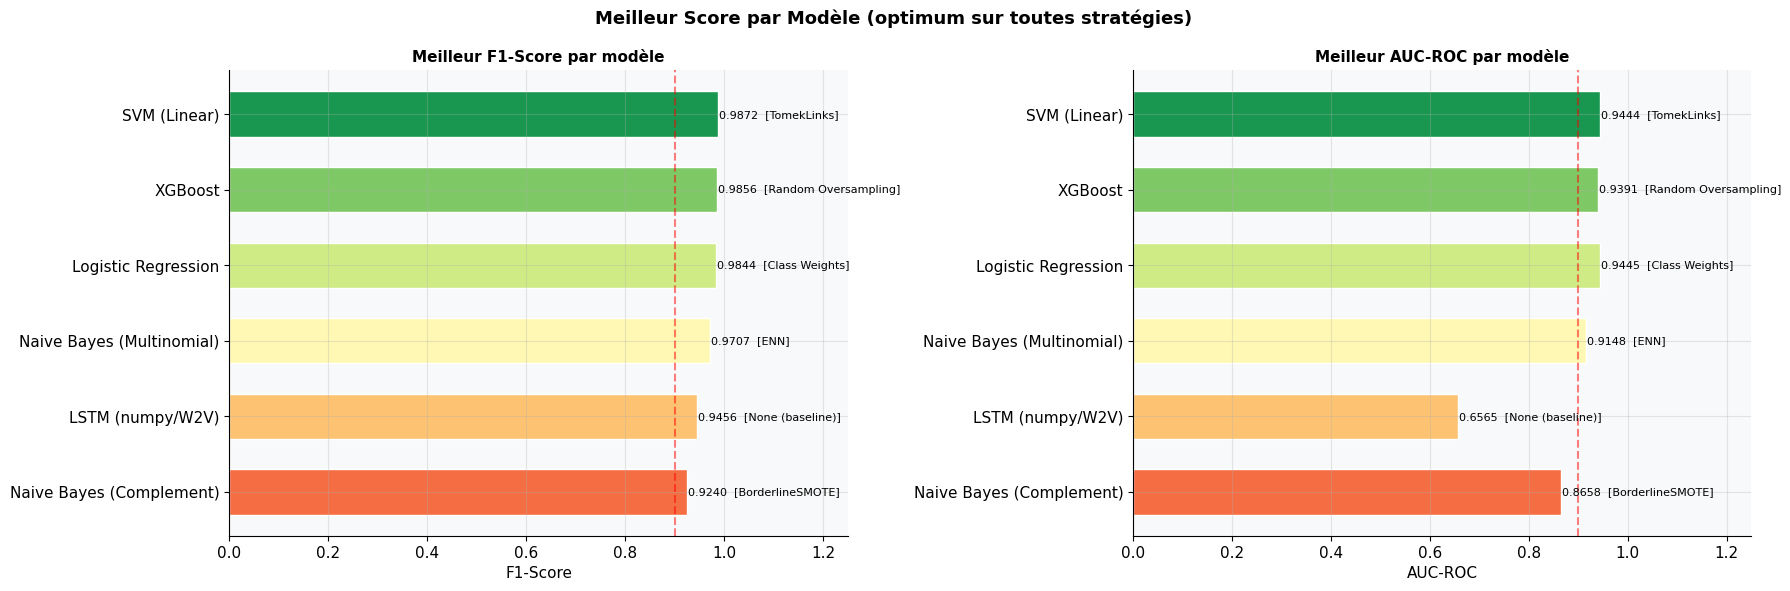

Figure 5 sauvegardée


In [25]:
# ── Figure 5 : Barplot F1 — meilleur résultat par modèle ─────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Meilleur Score par Modèle (optimum sur toutes stratégies)',
             fontsize=13, fontweight='bold')

best_per_model_sorted = best_per_model.sort_values('f1', ascending=True)

for ax, metric, title in [(axes[0], 'f1', 'F1-Score'), (axes[1], 'auc', 'AUC-ROC')]:
    values = best_per_model_sorted[metric].values
    names  = best_per_model_sorted['model'].values
    colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(names)))
    bars = ax.barh(names, values, color=colors_bar, edgecolor='white', height=0.6)
    for bar, val, row in zip(bars, values,
                              best_per_model_sorted.itertuples()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}  [{row.strategy}]',
                va='center', fontsize=8)
    ax.set_xlabel(title)
    ax.set_title(f'Meilleur {title} par modèle', fontsize=11)
    ax.set_xlim(0, 1.25)
    ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig5_best_per_model.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée')

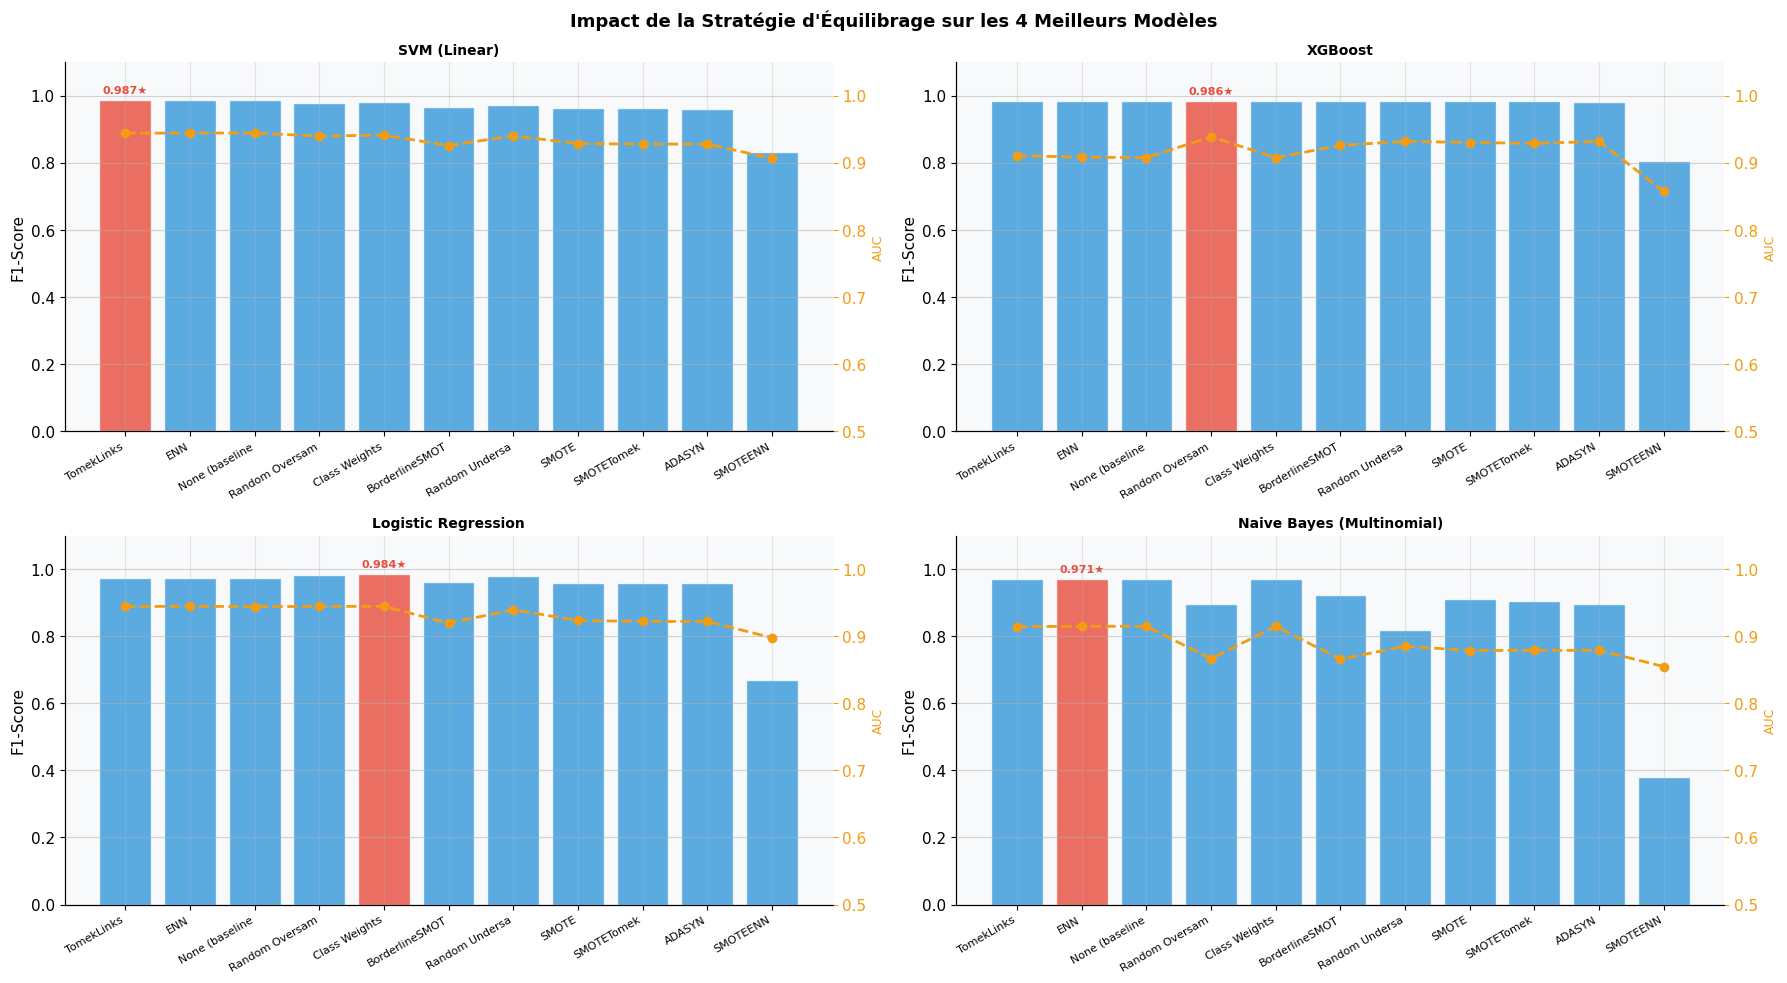

Figure 6 sauvegardée


In [26]:
# ── Figure 6 : Impact de la stratégie sur chaque modèle ──────
# Pour les 4 meilleurs modèles, evolution du F1 selon la stratégie
top4_models = best_per_model.head(4)['model'].tolist()
strat_order = best_per_strategy['strategy'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Impact de la Stratégie d\'Équilibrage sur les 4 Meilleurs Modèles',
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes.flatten(), top4_models):
    sub = results_df[results_df['model'] == model_name].copy()
    sub = sub.set_index('strategy').reindex(strat_order).reset_index()

    x  = range(len(sub))
    f1_vals  = sub['f1'].fillna(0).values
    auc_vals = sub['auc'].fillna(0).values

    color_bars = [COLORS['suspect'] if v == max(f1_vals) else COLORS['accent']
                  for v in f1_vals]
    bars = ax.bar(x, f1_vals, color=color_bars, alpha=0.8, edgecolor='white', label='F1')
    ax2 = ax.twinx()
    ax2.plot(x, auc_vals, 'o--', color=COLORS['gold'], linewidth=2,
             markersize=6, label='AUC')
    ax2.set_ylabel('AUC', color=COLORS['gold'], fontsize=9)
    ax2.set_ylim(0.5, 1.05)
    ax2.tick_params(axis='y', colors=COLORS['gold'])

    ax.set_xticks(x)
    ax.set_xticklabels([s[:14] for s in sub['strategy']],
                       rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1-Score')
    ax.set_title(f'{model_name}', fontsize=10)

    # Annotation du max
    best_idx = np.argmax(f1_vals)
    ax.text(best_idx, f1_vals[best_idx] + 0.02,
            f'{f1_vals[best_idx]:.3f}★', ha='center', fontsize=8,
            color=COLORS['suspect'], fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig6_strategy_impact.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 sauvegardée')

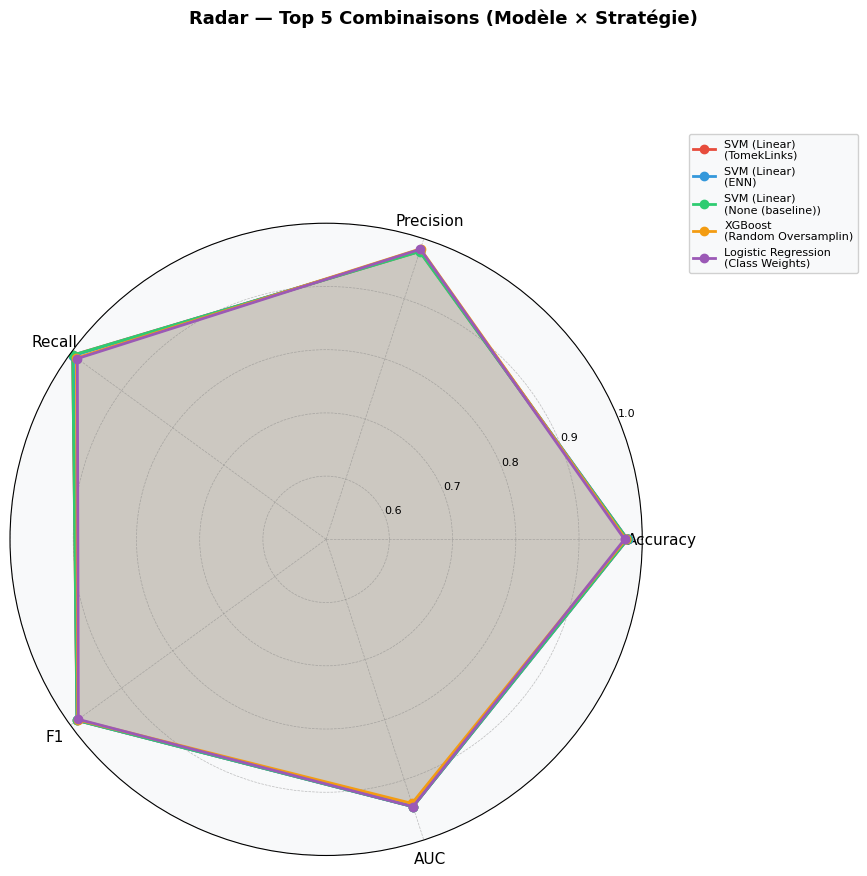

Figure 7 sauvegardée


In [27]:
# ── Figure 7 : Radar chart — top 5 combinaisons ──────────────
top5 = results_df.head(5).copy()
metrics_radar = ['accuracy', 'precision', 'recall', 'f1', 'auc']
labels_radar  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
fig.suptitle('Radar — Top 5 Combinaisons (Modèle × Stratégie)',
             fontsize=13, fontweight='bold', y=1.02)

colors_radar = [COLORS['suspect'], COLORS['accent'], COLORS['normal'],
                COLORS['gold'], COLORS['purple']]

for idx, (_, row) in enumerate(top5.iterrows()):
    values = [row[m] for m in metrics_radar]
    values += values[:1]
    label = f"{row['model'][:20]}\n({row['strategy'][:18]})"
    ax.plot(angles, values, 'o-', linewidth=2,
            color=colors_radar[idx], label=label)
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6', '0.7', '0.8', '0.9', '1.0'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=8, framealpha=0.9)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig7_radar_top5.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 sauvegardée')

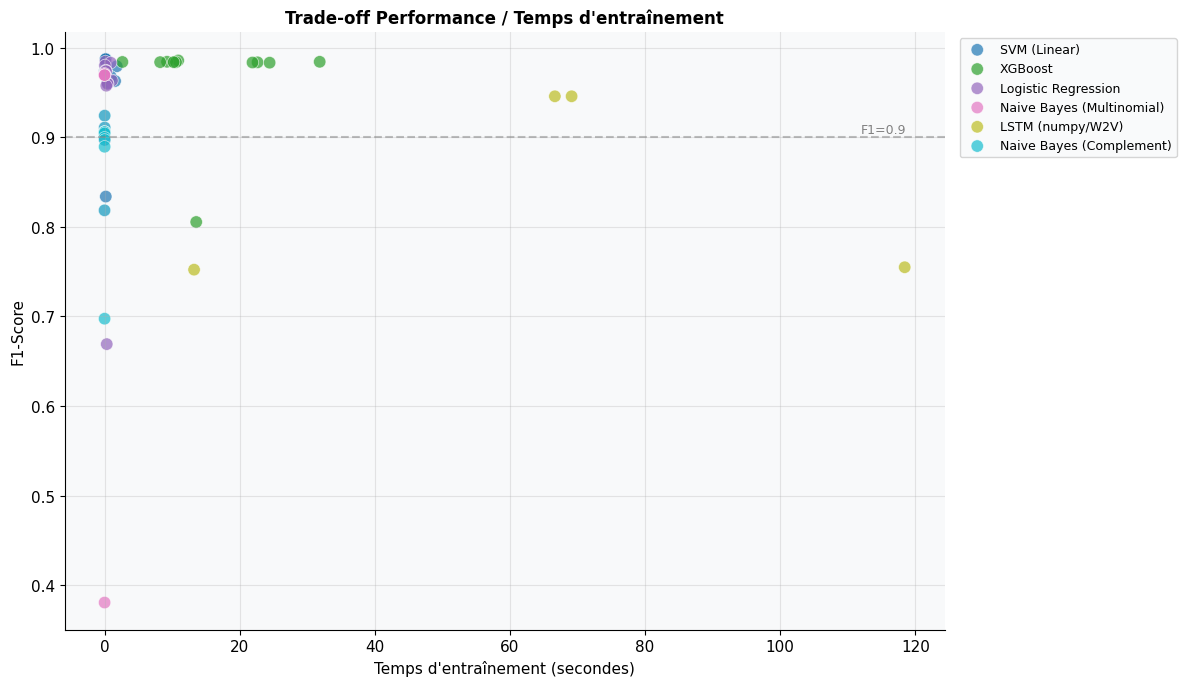

Figure 8 sauvegardée


In [28]:
# ── Figure 8 : Scatter F1 vs Temps d'entraînement ────────────
fig, ax = plt.subplots(figsize=(12, 7))
model_list = results_df['model'].unique()
cmap = plt.cm.tab10(np.linspace(0, 1, len(model_list)))
color_map = dict(zip(model_list, cmap))

for model_name in model_list:
    sub = results_df[results_df['model'] == model_name]
    ax.scatter(sub['train_s'], sub['f1'],
               c=[color_map[model_name]] * len(sub),
               s=80, alpha=0.7, edgecolors='white', linewidth=0.5,
               label=model_name)

ax.set_xlabel('Temps d\'entraînement (secondes)', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Trade-off Performance / Temps d\'entraînement',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
ax.text(ax.get_xlim()[1]*0.9, 0.905, 'F1=0.9', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(figure_save_base_dir, 'p4_fig8_tradeoff_perf_temps.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 sauvegardée')

<a id='6'></a>
## 6. Récapitulatif et choix final

In [29]:
# ── Sauvegarde des résultats ──────────────────────────────────
import os

# Ensure the 'outputs' directory exists before saving
os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/partie4_resultats_complets.csv', index=False)

# Ensure the 'metrics' directory exists before saving
os.makedirs('../metrics', exist_ok=True)

# Métriques pour DVC
best_row = results_df.iloc[0]
p4_metrics = {
    'best_combination': {
        'model'    : best_row['model'],
        'strategy' : best_row['strategy'],
        'f1'       : best_row['f1'],
        'auc'      : best_row['auc'],
        'accuracy' : best_row['accuracy'],
        'precision': best_row['precision'],
        'recall'   : best_row['recall'],
    },
    'total_combinations': len(results_df),
    'models_tested'     : results_df['model'].nunique(),
    'strategies_tested' : results_df['strategy'].nunique(),
}
with open('../metrics/partie4_metrics.json', 'w') as f:
    json.dump(p4_metrics, f, indent=2)

print('Résultats sauvegardés')
print()
print('=' * 70)
print('  RÉCAPITULATIF — PARTIE 4')
print('=' * 70)
print(f"""
  STRATÉGIES TESTÉES ({results_df['strategy'].nunique()} au total)
  ─────────────────────────────────────────────────────────────
  Surech.  : Random Oversampling, SMOTE, BorderlineSMOTE, ADASYN
  Souséch. : Random Undersampling, TomekLinks, ENN
  Hybride  : SMOTETomek, SMOTEENN
  Algo     : Class Weights
  Baseline : Aucun rééquilibrage

  MODÈLES TESTÉS ({results_df['model'].nunique()} au total)
  ─────────────────────────────────────────────────────────────
  Linéaires  : Logistic Regression, SVM (Linear),
  Probabiliste: Naive Bayes (Multinomial + Complement)
  Ensemble   : XGBoost
  Deep       : LSTM simplifié (numpy, Word2Vec)

  TOTAL COMBINAISONS ÉVALUÉES : {len(results_df)}

  MEILLEURE COMBINAISON
  ─────────────────────────────────────────────────────────────
  Modèle    : {best_row['model']}
  Stratégie : {best_row['strategy']}
  F1        : {best_row['f1']:.4f}
  AUC       : {best_row['auc']:.4f}
  Accuracy  : {best_row['accuracy']:.4f}
""")
print('=' * 70)

Résultats sauvegardés

  RÉCAPITULATIF — PARTIE 4

  STRATÉGIES TESTÉES (11 au total)
  ─────────────────────────────────────────────────────────────
  Surech.  : Random Oversampling, SMOTE, BorderlineSMOTE, ADASYN
  Souséch. : Random Undersampling, TomekLinks, ENN
  Hybride  : SMOTETomek, SMOTEENN
  Algo     : Class Weights
  Baseline : Aucun rééquilibrage

  MODÈLES TESTÉS (6 au total)
  ─────────────────────────────────────────────────────────────
  Linéaires  : Logistic Regression, SVM (Linear),
  Probabiliste: Naive Bayes (Multinomial + Complement)
  Ensemble   : XGBoost
  Deep       : LSTM simplifié (numpy, Word2Vec)

  TOTAL COMBINAISONS ÉVALUÉES : 59

  MEILLEURE COMBINAISON
  ─────────────────────────────────────────────────────────────
  Modèle    : SVM (Linear)
  Stratégie : TomekLinks
  F1        : 0.9872
  AUC       : 0.9444
  Accuracy  : 0.9768

